In [1]:
import langchain

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vishesh1412/celebrity-face-image-dataset")

print("Path to dataset files:", path)

In [2]:
import torch

In [3]:
from torchvision import datasets
from PIL import Image

# Your dataset path
dataset_path = r"D:\Facial-Media-Recognition-System\Dataset"

# Load using ImageFolder (gets image paths + labels)
dataset = datasets.ImageFolder(root=dataset_path)

# View first image and its label
img_path, label = dataset.samples[2]

# Load actual image
image = Image.open(img_path).convert("RGB")

# Show it (optional)
image.show()

# Print label
print("Class:", dataset.classes[label])


Class: Angelina Jolie


In [4]:
print(dataset.class_to_idx)


{'Angelina Jolie': 0, 'Brad Pitt': 1, 'Denzel Washington': 2, 'Hugh Jackman': 3, 'Jennifer Lawrence': 4, 'Johnny Depp': 5, 'Kate Winslet': 6, 'Leonardo DiCaprio': 7, 'Megan Fox': 8, 'Natalie Portman': 9, 'Nicole Kidman': 10, 'Robert Downey Jr': 11, 'Sandra Bullock': 12, 'Scarlett Johansson': 13, 'Tom Cruise': 14, 'Tom Hanks': 15, 'Will Smith': 16}


In [5]:
for images, labels in loader:
    print(images.shape)  # torch.Size([32, 3, 224, 224])
    print(labels.shape)  # torch.Size([32])
    break


NameError: name 'loader' is not defined

In [6]:
from transformers import AutoProcessor, AutoModel
from PIL import Image
import requests
import torch

# Choose an image embedding model (e.g., CLIP)
model_name = "openai/clip-vit-base-patch32"
# Load the processor (for image preprocessing) and the model
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# If you have a GPU, move the model to GPU for faster inference
if torch.cuda.is_available():
    model = model.cuda()

In [7]:
import os
import torch
import numpy as np
from PIL import Image
from torchvision import datasets
from transformers import AutoProcessor, AutoModel
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

# --- Configuration ---
DATASET_PATH = r"D:\Facial-Media-Recognition-System\Dataset"
HF_MODEL_NAME = "openai/clip-vit-base-patch32"

# --- 1. Load Hugging Face Model and Processor ---
processor = None
model = None

try:
    print(f"Loading Hugging Face model: {HF_MODEL_NAME}...")
    processor = AutoProcessor.from_pretrained(HF_MODEL_NAME)
    model = AutoModel.from_pretrained(HF_MODEL_NAME)

    if torch.cuda.is_available():
        model = model.cuda()
        print("Model moved to GPU for faster processing.")
    else:
        print("Running model on CPU.")

    print(f"Successfully loaded {HF_MODEL_NAME}\n")

except Exception as e:
    print(f"CRITICAL ERROR: Failed to load model '{HF_MODEL_NAME}': {e}")
    exit()

# --- 2. Define the Embedding Generation Function ---
def generate_image_embedding(pil_image: Image.Image, processor, model) -> np.ndarray:
    rgb_pil_image = pil_image.convert("RGB")
    inputs = processor(images=rgb_pil_image, return_tensors="pt")
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
    embedding = image_features.cpu().numpy().flatten()
    return embedding

# --- 3. Iterate Through the Entire Dataset and Generate Embeddings ---
if __name__ == "__main__":
    print(f"Preparing to process dataset from: {DATASET_PATH}")

    try:
        dataset = datasets.ImageFolder(root=DATASET_PATH)

        if not dataset.samples:
            print(f"No image samples found in '{DATASET_PATH}'. Please check your dataset structure.")
            exit()

        all_embeddings = []
        all_labels = []
        all_image_paths = []

        print(f"Found {len(dataset.samples)} images in the dataset. Starting embedding generation...")

        for idx, (img_path, label_idx) in enumerate(tqdm(dataset.samples, desc="Generating Embeddings")):
            try:
                image = Image.open(img_path)
                embedding = generate_image_embedding(image, processor, model)

                if embedding is not None:
                    all_embeddings.append(embedding)
                    all_labels.append(label_idx)
                    all_image_paths.append(img_path)
                else:
                    print(f"Skipping embedding for {img_path} due to error.")

            except Exception as e:
                print(f"Error processing image {img_path}: {e}")
                continue

        # --- 4. Process and Store the Results ---
        if all_embeddings:
            final_embeddings_array = np.array(all_embeddings)
            final_labels_array = np.array(all_labels)

            print("\n--- Embedding Generation Complete ---")
            print(f"Total images processed: {len(all_embeddings)}")
            print(f"Shape of all_embeddings_array: {final_embeddings_array.shape}")
            print(f"Shape of all_labels_array: {final_labels_array.shape}")

            output_dir = "generated_embeddings"
            os.makedirs(output_dir, exist_ok=True)
            embeddings_output_path = os.path.join(output_dir, "image_embeddings.npy")
            labels_output_path = os.path.join(output_dir, "image_labels.npy")
            paths_output_path = os.path.join(output_dir, "image_paths.txt")

            np.save(embeddings_output_path, final_embeddings_array)
            np.save(labels_output_path, final_labels_array)
            with open(paths_output_path, 'w') as f:
                for path in all_image_paths:
                    f.write(f"{path}\n")

            print(f"Embeddings saved to: {embeddings_output_path}")
            print(f"Labels saved to: {labels_output_path}")
            print(f"Image paths saved to: {paths_output_path}")
            print(f"Dataset class names: {dataset.classes}")

            # --- 5. Load New Image and Find Similar Images ---
            print("\n--- Similarity Search for New Image ---")
            try:
                new_image_path = r"D:\Facial-Media-Recognition-System\test\Test.jpg" # CHANGE THIS PATH
                new_image = Image.open(new_image_path)

                # Load stored embeddings and image paths
                embeddings = np.load(embeddings_output_path)
                with open(paths_output_path, 'r') as f:
                    image_paths = [line.strip() for line in f.readlines()]

                # Generate embedding for new image
                new_embedding = generate_image_embedding(new_image, processor, model)

                # Calculate cosine similarity
                similarities = cosine_similarity([new_embedding], embeddings)[0]
                top_k = 5
                top_indices = similarities.argsort()[::-1][:top_k]

                print(f"\nTop {top_k} similar images to: {new_image_path}")
                for idx in top_indices:
                    print(f"{image_paths[idx]} — Similarity: {similarities[idx]:.4f}")

            except Exception as e:
                print(f"Error during similarity search: {e}")

        else:
            print("No embeddings were generated. Check for errors during processing.")

    except Exception as e:
        print(f"An unexpected error occurred during dataset processing: {e}")


Loading Hugging Face model: openai/clip-vit-base-patch32...
Model moved to GPU for faster processing.
Successfully loaded openai/clip-vit-base-patch32

Preparing to process dataset from: D:\Facial-Media-Recognition-System\Dataset
Found 1800 images in the dataset. Starting embedding generation...


Generating Embeddings: 100%|██████████| 1800/1800 [00:29<00:00, 61.80it/s]



--- Embedding Generation Complete ---
Total images processed: 1800
Shape of all_embeddings_array: (1800, 512)
Shape of all_labels_array: (1800,)
Embeddings saved to: generated_embeddings\image_embeddings.npy
Labels saved to: generated_embeddings\image_labels.npy
Image paths saved to: generated_embeddings\image_paths.txt
Dataset class names: ['Angelina Jolie', 'Brad Pitt', 'Denzel Washington', 'Hugh Jackman', 'Jennifer Lawrence', 'Johnny Depp', 'Kate Winslet', 'Leonardo DiCaprio', 'Megan Fox', 'Natalie Portman', 'Nicole Kidman', 'Robert Downey Jr', 'Sandra Bullock', 'Scarlett Johansson', 'Tom Cruise', 'Tom Hanks', 'Will Smith']

--- Similarity Search for New Image ---

Top 5 similar images to: D:\Facial-Media-Recognition-System\test\Test.jpg
D:\Facial-Media-Recognition-System\Dataset\Brad Pitt\100_f4b2c7a7.jpg — Similarity: 1.0000
D:\Facial-Media-Recognition-System\Dataset\Brad Pitt\058_ca613f72.jpg — Similarity: 0.8998
D:\Facial-Media-Recognition-System\Dataset\Brad Pitt\077_ddf0abd8.

In [68]:
print(f"Image paths saved to: {paths_output_path}")
print(f"Dataset class names: {dataset.classes}")


Image paths saved to: generated_embeddings\image_paths.txt
Dataset class names: ['Angelina Jolie', 'Brad Pitt', 'Denzel Washington', 'Hugh Jackman', 'Jennifer Lawrence', 'Johnny Depp', 'Kate Winslet', 'Leonardo DiCaprio', 'Megan Fox', 'Natalie Portman', 'Nicole Kidman', 'Robert Downey Jr', 'Sandra Bullock', 'Scarlett Johansson', 'Tom Cruise', 'Tom Hanks', 'Will Smith']


In [48]:
image_embedding.shape

(512,)

In [50]:
import numpy as np

embeddings = np.load("generated_embeddings/image_embeddings.npy")
labels = np.load("generated_embeddings/image_labels.npy")
with open("generated_embeddings/image_paths.txt") as f:
    paths = f.read().splitlines()


In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [60]:

# Load and embed the query image
query_path = r"D:\Facial-Media-Recognition-System\test\Test.jpg"
query_image = Image.open(query_path).convert("RGB")

inputs = processor(images=query_image, return_tensors="pt").to(device)

with torch.no_grad():
    query_embedding = model.get_image_features(**inputs).cpu().numpy()[0]  # shape: (512,)


In [62]:
from sklearn.metrics.pairwise import cosine_similarity

# Reshape for compatibility (1, 512)
query_embedding = query_embedding.reshape(1, -1)

# Compute cosine similarity
similarities = cosine_similarity(query_embedding, embeddings)  # shape: (1, N)
similarities = similarities[0]  # shape: (N,)


In [64]:
# Top 5 most similar indices
top_k = 5
top_indices = similarities.argsort()[-top_k:][::-1]

# Print results
print("\nTop similar images:")
for rank, idx in enumerate(top_indices, start=1):
    print(f"(score: {similarities[idx]:.4f})")



Top similar images:
(score: 1.0000)
(score: 0.8998)
(score: 0.8224)
(score: 0.8186)
(score: 0.8153)


NameError: name 'query_image' is not defined

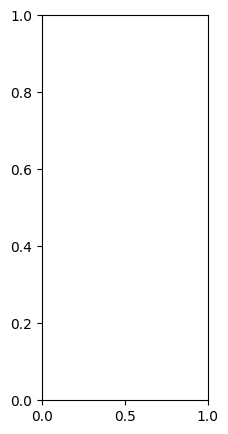

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

# Show query image
plt.figure(figsize=(15, 5))
plt.subplot(1, 6, 1)
plt.imshow(query_image)
plt.title("Query")
plt.axis("off")

# Show top similar images
for i, idx in enumerate(top_indices):
    similar_img = Image.open(image_paths[idx])
    plt.subplot(1, 6, i + 2)
    plt.imshow(similar_img)
    plt.title(f"Match {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
import matplotlib.pyplot as plt  # Add at the top of your file if not already imported

def find_similar_images(query_image_path, top_k=5):
    try:
        query_image = Image.open(query_image_path)
        query_embedding = generate_image_embedding(query_image, processor, model)

        # Compute cosine similarity between query and all dataset embeddings
        similarities = cosine_similarity(
            [query_embedding],
            final_embeddings_array
        )[0]

        # Get top-k similar image indices
        top_k_indices = np.argsort(similarities)[-top_k:][::-1]

        print("\nTop similar images:")
        for rank, idx in enumerate(top_k_indices):
            print(f"{rank + 1}: {all_image_paths[idx]} (Score: {similarities[idx]:.4f})")

        # --- Display top-k images ---
        fig, axes = plt.subplots(1, top_k, figsize=(15, 5))
        for i, idx in enumerate(top_k_indices):
            img = Image.open(all_image_paths[idx])
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(f"{i+1}\nScore: {similarities[idx]:.2f}")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error during comparison: {e}")



Top similar images:
1: D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\019_99363fad.jpg (Score: 1.0000)
2: D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\026_f06834e9.jpg (Score: 0.9029)
3: D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\084_31281f33.jpg (Score: 0.8976)
4: D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\029_ea3de34c.jpg (Score: 0.8927)
5: D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\016_9959338f.jpg (Score: 0.8641)
6: D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\035_34c306d1.jpg (Score: 0.8601)
7: D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\052_60af6c54.jpg (Score: 0.8596)
8: D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\063_5b917fac.jpg (Score: 0.8501)
9: D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\093_7e0d43d2.jpg (Score: 0.8434)
10: D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\028_a41d259d.jpg (Score: 0.8407)


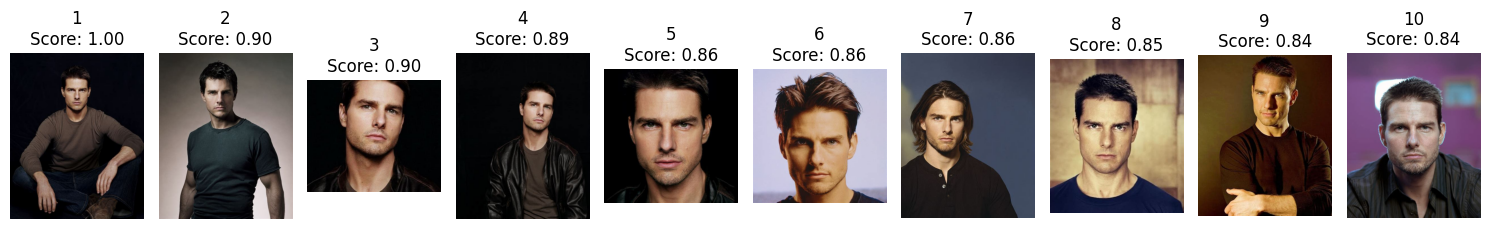

In [15]:
QUERY_IMAGE =r"D:\Facial-Media-Recognition-System\Dataset\Tom Cruise\019_99363fad.jpg"
find_similar_images(QUERY_IMAGE, top_k=10)
